Tests out the computer vision side of things, thresholding, dot recognition, color recognition.

In [2]:
from pathlib import Path
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

In [32]:
## Input images (Knob 1)
def inputImage(path, pltShow=False):
    img_path = Path("../webcam_storage/" + path + ".jpg")
    image = cv.imread(img_path, cv.IMREAD_COLOR_RGB)
    if pltShow:
        print(path)
        plt.imshow(image)
        plt.show()
    return image


# /Users/jdreiling/Desktop/puck/puck/webcam_storage/customs/single_boxes/cm1/setA1.jpg

/customs/single_boxes/cm1/setA


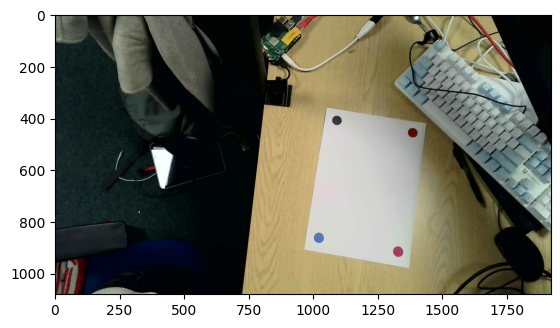

/customs/single_boxes/cm1/setB


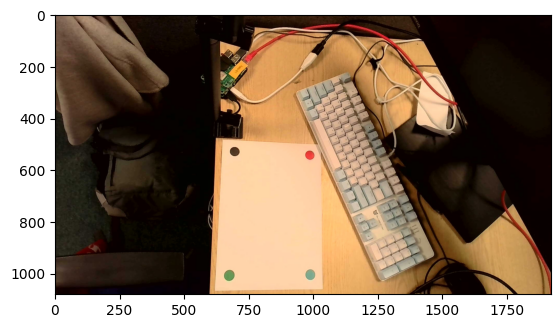

/customs/single_boxes/cm1/setC


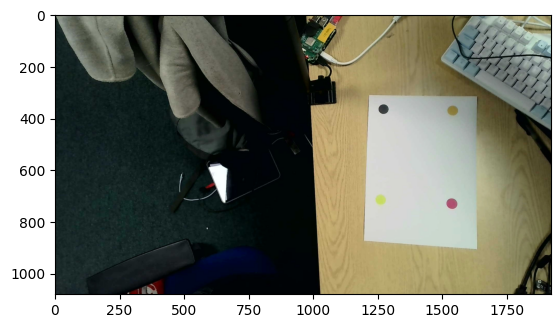

/customs/single_boxes/cm1/setD


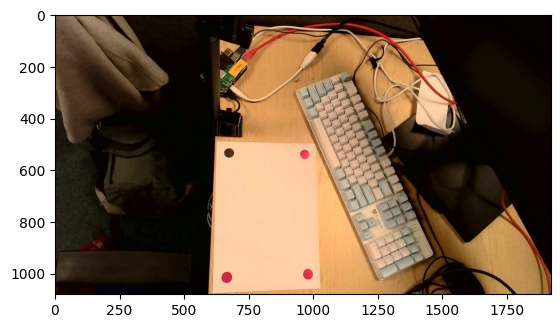

In [ ]:
list = ["A", "B", "C", "D"]
size = "/cm1"
colorPal = "/customs"
boxCount = ("/single_boxes",4)
paths = [colorPal + boxCount[0] + size + "/set"+ path  for path in list]


In [ ]:
## Image Preprocessing (Knob 2)
def preprocess(image, pltShow = False):
    imageBlurred = cv.medianBlur(image, 5)
    gray = cv.cvtColor(imageBlurred, cv.COLOR_RGBA2GRAY)
    if pltShow:
        print("Gray Scale")
        plt.imshow(gray, cmap="gray")
        plt.show()
    return gray

In [ ]:
## Image Thresholding (Knob 3)
def threshold(gray, criteria, pltShow = False):
    _, thesholded = cv.threshold(gray, 180, 255, criteria)
    if pltShow:
        print("Gray Scale")
        plt.imshow(thesholded, cmap="gray")
        plt.show()

In [ ]:
## Blob Detector Settings (Knobs 4 and 5)
def blobParams(minCircularity, minArea):
    params = cv.SimpleBlobDetector_Params()
    params.filterByCircularity = True
    params.minCircularity = minCircularity
    params.minArea=minArea
    return params

In [ ]:
## Pipeline
def pipeline(imageList, sucessDict, detector):
    for path in imageList:
        image = inputImage(path)
        gray = preprocess(image)
        thresholded = threshold(gray)
        keypoints = detector.detect(thresholded)
        blank = np.zeros((1, 1))
        blobs = cv.drawKeypoints(image, keypoints, blank, (255, 0, 0), cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
        if len(keypoints) == 4:
            sucessDict.update({path:True})

    return pd.DataFrame(sucessDict)

In [34]:
blobParams = blobParams(.5,100)
detector = cv.SimpleBlobDetector_create(blobParams)
list = ["A", "B", "C", "D"]
size = "/cm1"
colorPal = "/darks"
boxCount = ("/single_boxes",4)
paths = [colorPal + boxCount[0] + size + "/set"+ path  for path in list]
sucessDict = {}
sucessDF = pipeline(paths, sucessDict, detector)
sucessDF.to_csv(colorPal[1:] + boxCount[0][1:] + size[1:] + ".csv")


NameError: name 'blobParams' is not defined

True
True
True
True


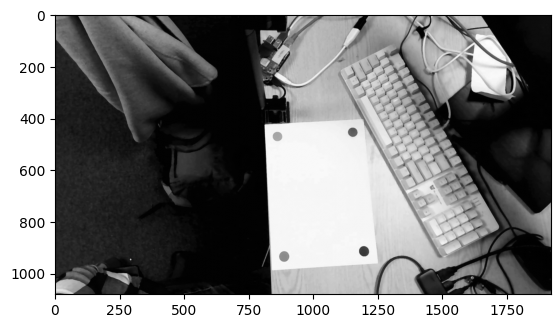

Blobs detected


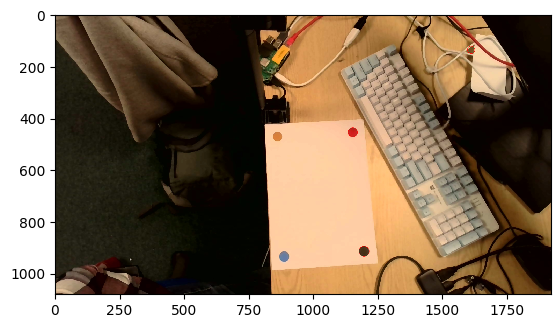

True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True


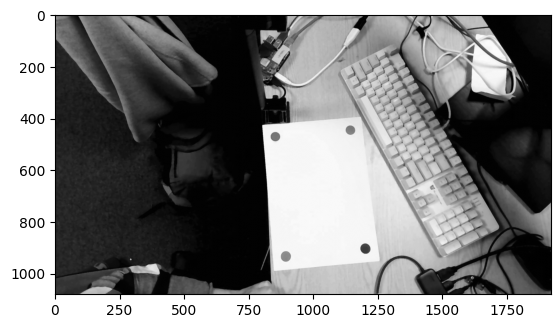

Blobs detected


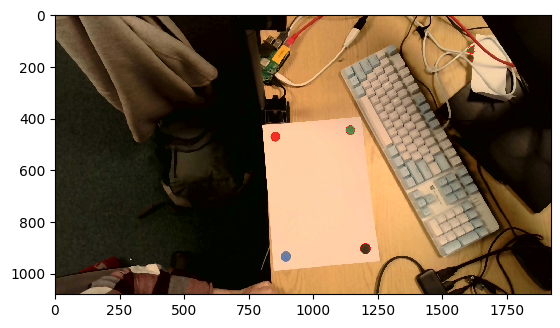

True
True
True
True
True
True
True
True
True
True


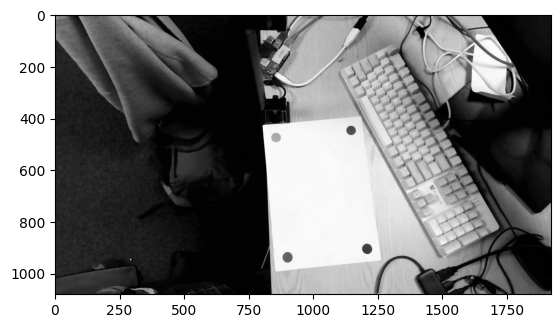

Blobs detected


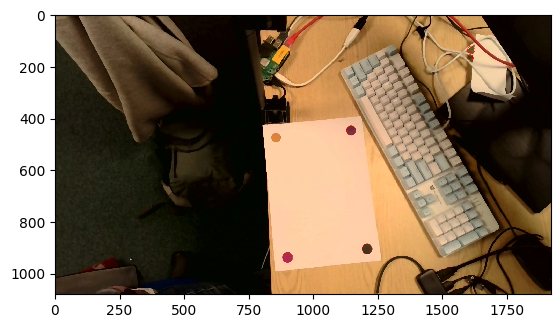

True
True
True
True
True
True
True
True
True
True
True
True


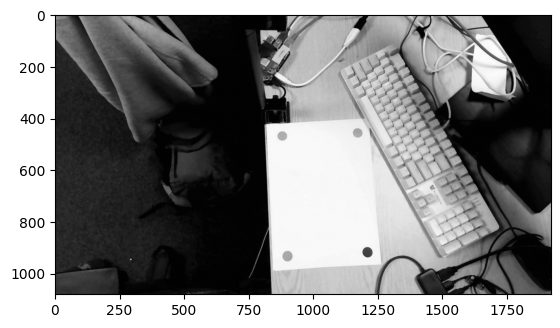

Blobs detected


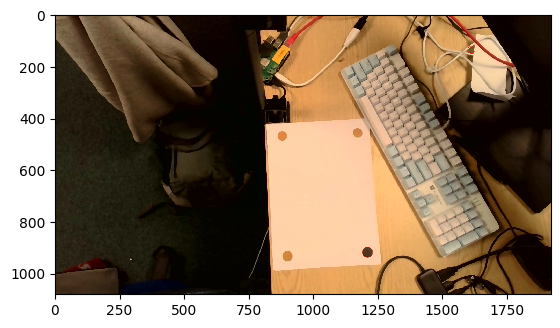

True
True
True
True
True
True
True
True
True
    setDarkA1  setDarkB1  setDarkC1  setDarkD1
0         0.0        0.0        0.0        0.0
1         0.0        0.0        0.0        0.0
2         0.0        0.0        0.0        0.0
3         0.0        0.0        0.0        0.0
4         0.0        0.0        1.0        0.0
5         0.0        0.0        0.0        0.0
6         0.0        1.0        0.0        0.0
7         0.0        0.0        0.0        0.0
8         0.0        0.0        0.0        0.0
9         0.0        0.0        0.0        0.0
10        0.0        0.0        0.0        0.0
11        0.0        0.0        0.0        0.0
12        0.0        0.0        0.0        0.0
13        0.0        0.0        0.0        0.0
14        0.0        0.0        0.0        1.0
15        0.0        1.0        0.0        0.0
16        0.0        0.0        0.0        0.0
17        1.0        1.0        0.0        0.0
18        0.0        0.0        0.0        0.0
19        0.0  

In [ ]:
from pathlib import Path
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

imageSet = ["setDarkA1", "setDarkB1", "setDarkC1", "setDarkD1"]

sucessDict = {}

for img in imageSet:
    img_path = Path("frames/" + img + ".jpg")
    image = cv.imread(img_path, cv.IMREAD_COLOR_RGB)
    sucesses = np.zeros(51)
    for i in range(0,255, 5):
        image = cv.imread(img_path, cv.IMREAD_COLOR_RGB)
        image = cv.medianBlur(image, 5)
        gray = cv.cvtColor(image, cv.COLOR_RGBA2GRAY)
        _, thesholded = cv.threshold(gray, i, 255, cv.THRESH_BINARY)
        params = cv.SimpleBlobDetector_Params()
        params.filterByCircularity = True
        params.minCircularity = 0.5
        params.minArea=100
        detector = cv.SimpleBlobDetector_create(params)
        keypoints = detector.detect(thesholded)
        blank = np.zeros((1, 1))
        # render  - where the coordinate system will be founds
        blobs = cv.drawKeypoints(
            image, keypoints, blank, (255, 0, 0), cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
        )
        if len(keypoints) == 4:
            sucesses[int(i/5)] = 1
            print(len(keypoints) == 4)
        if i == 120:
            plt.imshow(gray, cmap="gray")
            plt.show()
            print("Blobs detected")
            #blit 
            plt.imshow(blobs, interpolation="nearest")
            plt.show()
            
    sucessDict.update({img:sucesses})

sucessDF = pd.DataFrame(sucessDict)
print(pd.DataFrame(sucessDF))
sucessDF.to_csv('sucessDFDarksOTSU.csv')



In [7]:
test = [i for i in range(0,255, 5)]
for x in test:
    print(x/5)

0.0
1.0
2.0
3.0
4.0
5.0
6.0
7.0
8.0
9.0
10.0
11.0
12.0
13.0
14.0
15.0
16.0
17.0
18.0
19.0
20.0
21.0
22.0
23.0
24.0
25.0
26.0
27.0
28.0
29.0
30.0
31.0
32.0
33.0
34.0
35.0
36.0
37.0
38.0
39.0
40.0
41.0
42.0
43.0
44.0
45.0
46.0
47.0
48.0
49.0
50.0


In [ ]:
tes2t = np.zeros(51)
len(tes2t)


51

In [10]:
for kp in keypoints:
    print(kp.pt)

print(len(keypoints))

(1199.3902587890625, 941.461669921875)
(1905.242431640625, 857.0800170898438)
(1719.5933837890625, 656.5144653320312)
(952.0318603515625, 443.0149841308594)
4


In [ ]:
from dataclasses import dataclass
from math import hypot


@dataclass
class Point:
    x: float = 0.0
    y: float = 0.0

    @classmethod
    def from_tuple(cls, coords):
        return cls(coords[0], coords[1])

    def as_tuple(self):
        return (self.x, self.y)


def euc_dist(a: Point, b: Point) -> float:
    return hypot(b.x - a.x, b.y - a.y)


points = [Point.from_tuple(kp.pt) for kp in keypoints]

print(f"There are {len(points)} points in the image.")

In [ ]:
# lets test out the finding rectangles stuff
from itertools import combinations


# util function used to put the distances into buckets
def bucket(value: float, size: float):
    return int(value / size)


# compute all the unordered pairs
pairs = list(combinations(points, 2))

print(f"There are {len(pairs)} pairs of points.")
pairs

In [ ]:
# work out the distances between each pair
bucketed = [bucket(euc_dist(a, b), 5) for a, b in pairs]

print(f"There are {len(list(set(bucketed)))} pairs of different distances.")

In [ ]:
# find the lines with approx the same lengths
from collections import defaultdict


tally = defaultdict(list)

for pair, dist in zip(pairs, bucketed):
    tally[dist].append(pair)
same_distance_pairs = dict(
    ((dist, pairs) for dist, pairs in tally.items() if len(pairs) > 1)
)
same_distance_pairs
print(tally)